# 动量因子研究

**研究目标**：计算多周期动量因子，分析 A 股市场动量 vs 反转效应，与极坐标因子对比。

**研究框架**：
1. 数据准备：沪深300成分股，2019-2024
2. 多周期动量因子计算（5/10/20/60/120日）
3. IC/ICIR 分析
4. 分层回测（十分位）
5. 与极坐标价量因子相关性分析
6. 结论

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 项目模块
from utils import (
    get_index_components, build_price_matrix, build_return_matrix,
    compute_ic_series, ic_summary, quintile_backtest, factor_summary_table,
)
from research.factors.momentum.momentum_factor import (
    compute_momentum, compute_multi_period_momentum, equal_weight_composite,
)

# 中文字体
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

print("✅ 模块加载完成")

✅ 模块加载完成


## 1. 数据准备

获取沪深300成分股的日线收盘价数据（前复权），时间跨度 5 年。

In [2]:
# 参数设置
START = "2019-01-01"
END = "2023-12-31"
FWD_DAYS = 5  # 前瞻收益天数（与极坐标因子一致，便于对比）

# 获取沪深300成分股
hs300 = get_index_components("000300")
symbols = hs300["symbol"].tolist()
print(f"沪深300成分股数量: {len(symbols)}")

# 构建价格宽表（会自动缓存到 data/processed/）
price_wide = build_price_matrix(symbols, START, END, col="close", max_workers=4)
print(f"价格宽表形状: {price_wide.shape}")
print(f"日期范围: {price_wide.index[0]} ~ {price_wide.index[-1]}")

# 构建收益率宽表
ret_wide = build_return_matrix(price_wide)
print(f"收益率宽表形状: {ret_wide.shape}")

# 构建 N 日前瞻收益（用于 IC 分析）
fwd_ret = price_wide.pct_change(FWD_DAYS).shift(-FWD_DAYS)
print(f"前瞻收益宽表形状: {fwd_ret.shape}")

沪深300成分股数量: 300


下载中:   0%|                                           | 0/300 [00:00<?, ?it/s]

下载中:   0%|                                   | 1/300 [00:01<06:39,  1.34s/it]

下载中:   2%|▌                                  | 5/300 [00:02<02:04,  2.37it/s]

下载中:   3%|█                                  | 9/300 [00:05<03:06,  1.56it/s]

...

下载中:  99%|████████████████████████████████▊| 298/300 [05:15<00:01,  1.15it/s]

下载中: 100%|████████████████████████████████▉| 299/300 [05:16<00:00,  1.20it/s]

下载中: 100%|█████████████████████████████████| 300/300 [05:19<00:00,  1.27s/it]

下载中: 100%|█████████████████████████████████| 300/300 [05:19<00:00,  1.06s/it]

✅ 成功: 8/300 只
✅ 价格宽表已缓存: price_wide_close_2019-01-01_2023-12-31_qfq_300stocks.parquet  形状: (1214, 8)
价格宽表形状: (1214, 8)
日期范围: 2019-01-02 00:00:00 ~ 2023-12-29 00:00:00
收益率宽表形状: (1213, 8)
前瞻收益宽表形状: (1214, 8)


## 2. 计算多周期动量因子

计算 5/10/20/60/120 日动量因子，skip=1（跳过最近1天，避免反转噪音）。

In [3]:
# 计算多周期动量因子
PERIODS = [5, 10, 20, 60, 120]
momentum_factors = compute_multi_period_momentum(price_wide, periods=PERIODS, skip=1)

for p, fac in momentum_factors.items():
    valid_pct = fac.notna().sum().sum() / (fac.shape[0] * fac.shape[1])
    print(f"动量_{p}日: 形状 {fac.shape}, 有效率 {valid_pct:.1%}")

动量_5日: 形状 (1214, 8), 有效率 99.1%
动量_10日: 形状 (1214, 8), 有效率 98.6%
动量_20日: 形状 (1214, 8), 有效率 97.8%
动量_60日: 形状 (1214, 8), 有效率 94.5%
动量_120日: 形状 (1214, 8), 有效率 89.7%


## 3. IC/ICIR 分析

使用 Rank IC（Spearman 相关系数），前瞻收益为 5 日收益率。

In [4]:
# 计算各周期 IC 序列
ic_series_dict = {}
ic_summaries = {}

for p in PERIODS:
    fac = momentum_factors[p]
    ic_s = compute_ic_series(fac, fwd_ret, method="spearman")
    ic_series_dict[p] = ic_s
    ic_summaries[p] = ic_summary(ic_s, name=f"动量_{p}日")

【动量_5日】IC 统计摘要
  IC 均值    : nan
  IC 标准差  : nan
  ICIR       : nan
  IC>0 占比  : nan%
  t 统计量   : nan  (|t|>2 视为显著)



【动量_10日】IC 统计摘要
  IC 均值    : nan
  IC 标准差  : nan
  ICIR       : nan
  IC>0 占比  : nan%
  t 统计量   : nan  (|t|>2 视为显著)



【动量_20日】IC 统计摘要
  IC 均值    : nan
  IC 标准差  : nan
  ICIR       : nan
  IC>0 占比  : nan%
  t 统计量   : nan  (|t|>2 视为显著)

【动量_60日】IC 统计摘要
  IC 均值    : nan
  IC 标准差  : nan
  ICIR       : nan
  IC>0 占比  : nan%
  t 统计量   : nan  (|t|>2 视为显著)



【动量_120日】IC 统计摘要
  IC 均值    : nan
  IC 标准差  : nan
  ICIR       : nan
  IC>0 占比  : nan%
  t 统计量   : nan  (|t|>2 视为显著)



In [5]:
# IC 汇总表
summary_table = factor_summary_table(
    {f"动量_{p}日": momentum_factors[p] for p in PERIODS},
    fwd_ret,
)
print(summary_table.to_string(index=False))

     因子  IC均值(spearman)  ICIR IC>0占比 多空年化  多空夏普
  动量_5日             NaN   NaN   nan% nan%   NaN
 动量_10日             NaN   NaN   nan% nan%   NaN
 动量_20日             NaN   NaN   nan% nan%   NaN
 动量_60日             NaN   NaN   nan% nan%   NaN
动量_120日             NaN   NaN   nan% nan%   NaN


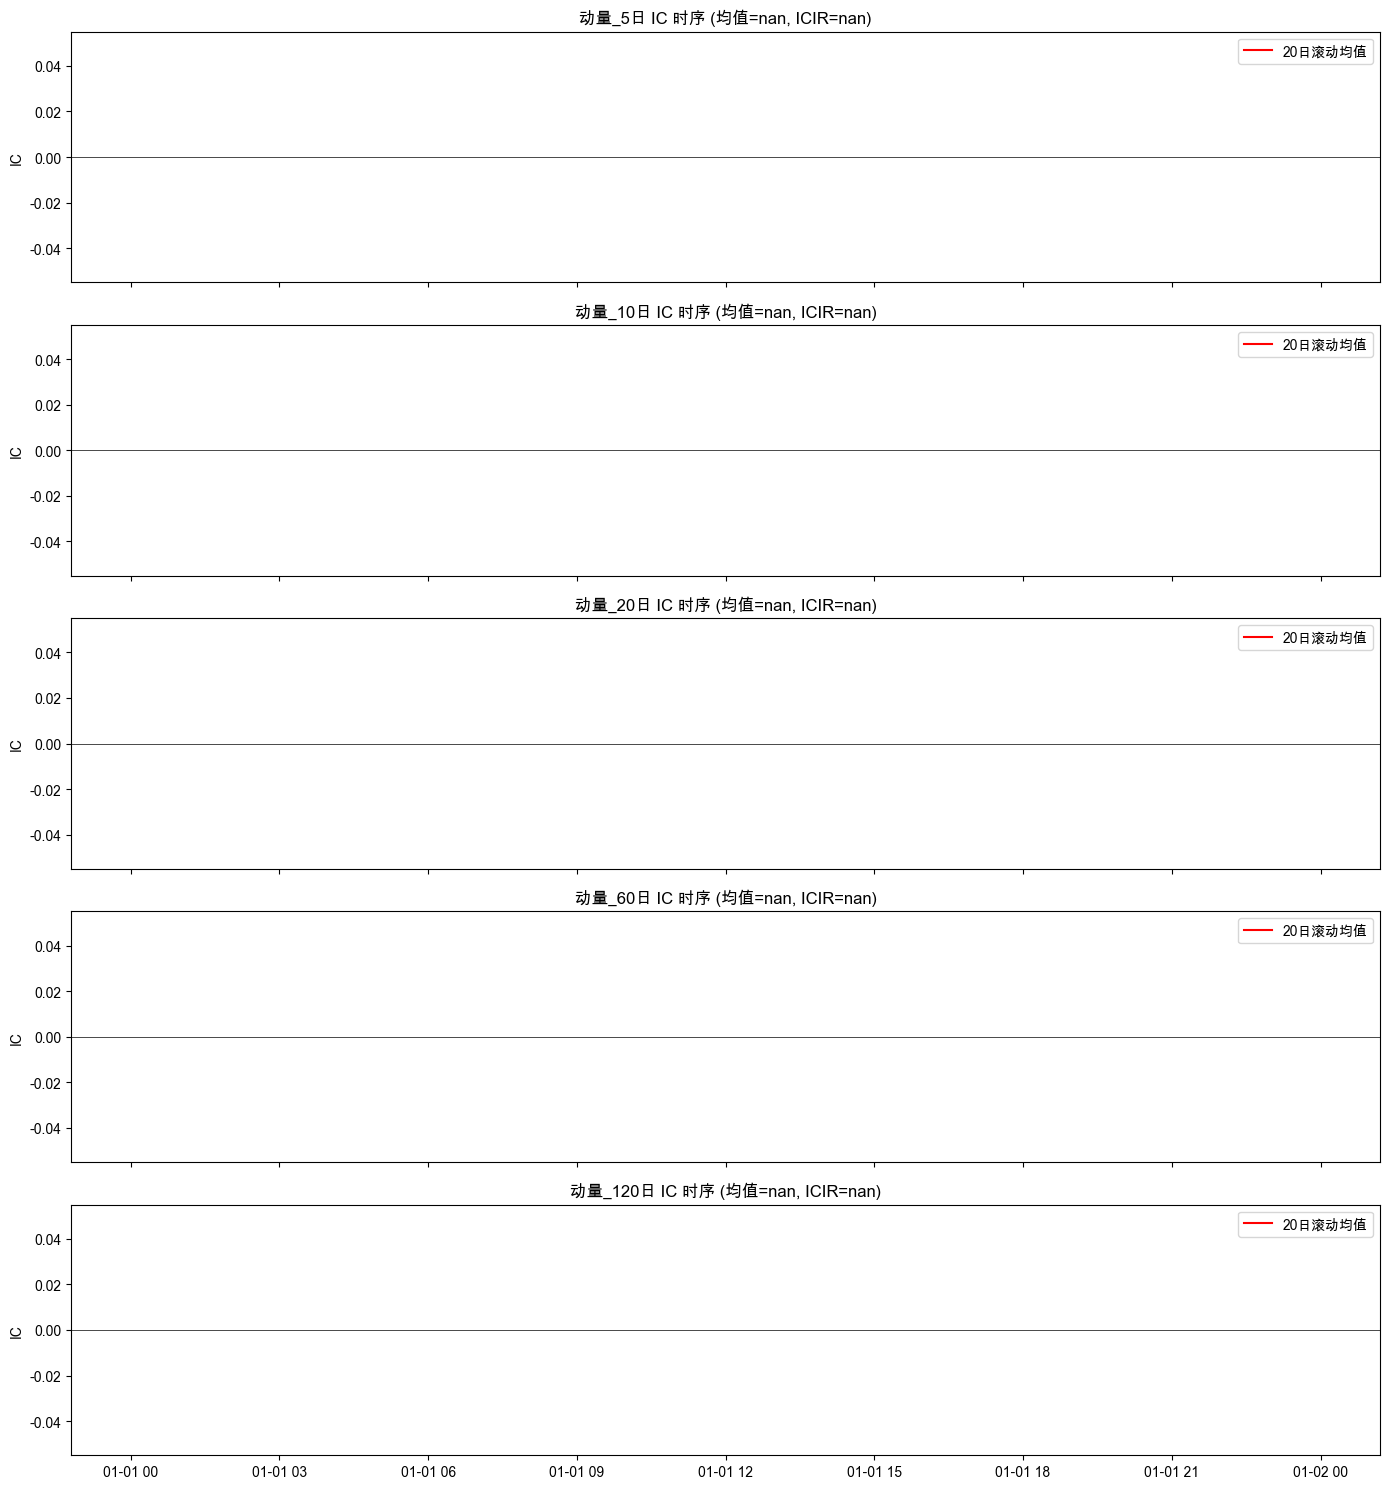

In [6]:
# IC 时序图
fig, axes = plt.subplots(len(PERIODS), 1, figsize=(14, 3 * len(PERIODS)), sharex=True)

for i, p in enumerate(PERIODS):
    ax = axes[i]
    ic_s = ic_series_dict[p].dropna()
    # 滚动 20 日均值
    ic_rolling = ic_s.rolling(20).mean()
    ax.bar(ic_s.index, ic_s.values, alpha=0.3, color="steelblue", width=1)
    ax.plot(ic_rolling.index, ic_rolling.values, color="red", linewidth=1.5, label="20日滚动均值")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("IC")
    ax.set_title(f"动量_{p}日 IC 时序 (均值={ic_s.mean():.4f}, ICIR={ic_s.mean()/ic_s.std():.4f})")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 4. 分层回测（十分位）

按因子值将股票分为 10 组，计算各组平均收益，观察单调性。

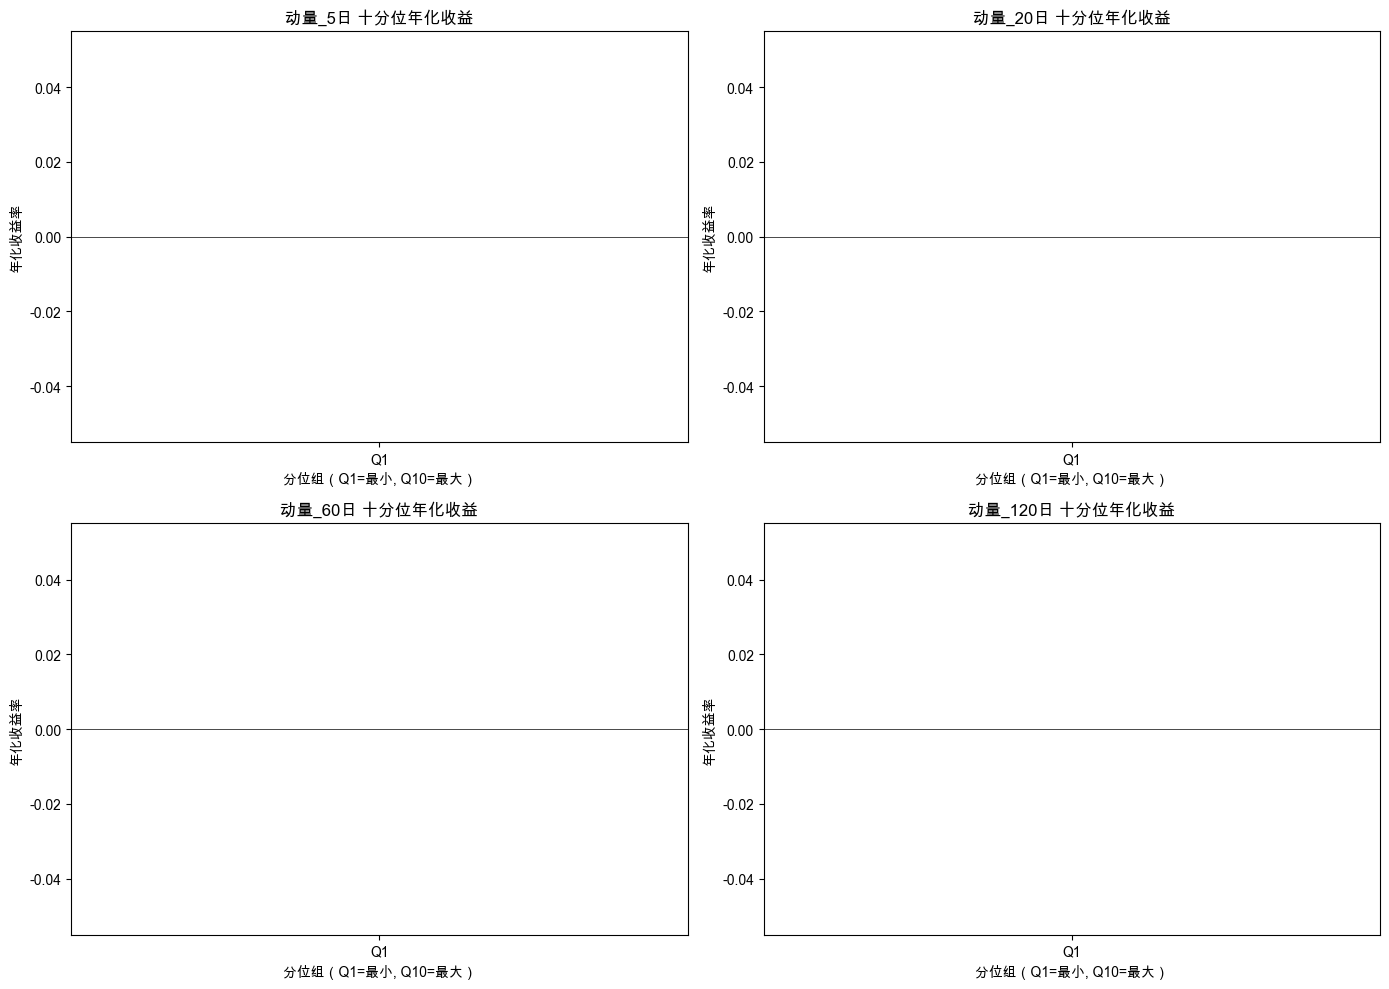

In [7]:
# 选择代表性周期做分层回测
test_periods = [5, 20, 60, 120]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, p in enumerate(test_periods):
    ax = axes[idx // 2][idx % 2]
    fac = momentum_factors[p]
    
    # 十分位回测
    group_ret, ls_ret = quintile_backtest(fac, fwd_ret, n_groups=10, long_short="Qn_minus_Q1")
    
    # 各组累计收益柱状图
    avg_ret = group_ret.mean() * 252  # 年化
    colors = ["#d73027" if v < 0 else "#4575b4" for v in avg_ret.values]
    ax.bar(avg_ret.index, avg_ret.values, color=colors, alpha=0.8)
    ax.set_title(f"动量_{p}日 十分位年化收益")
    ax.set_xlabel("分位组（Q1=最小, Q10=最大）")
    ax.set_ylabel("年化收益率")
    ax.axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

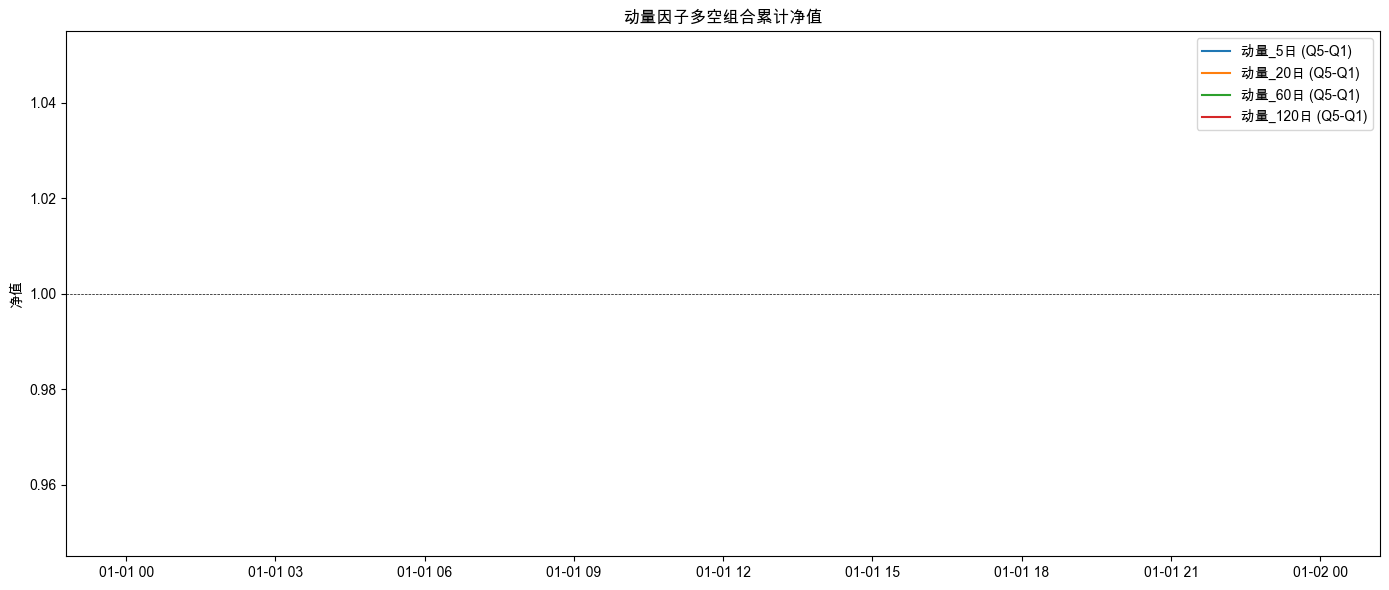

In [8]:
# 多空组合净值曲线
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

for p in test_periods:
    fac = momentum_factors[p]
    _, ls_ret = quintile_backtest(fac, fwd_ret, n_groups=5, long_short="Qn_minus_Q1")
    cum_ret = (1 + ls_ret.dropna()).cumprod()
    ax.plot(cum_ret.index, cum_ret.values, label=f"动量_{p}日 (Q5-Q1)")

ax.set_title("动量因子多空组合累计净值")
ax.set_ylabel("净值")
ax.legend()
ax.axhline(1, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

## 5. 与极坐标价量因子的相关性

计算动量因子与极坐标因子的截面相关性，判断两者是否正交（低相关 = 适合组合）。

> 注：如果极坐标因子数据不可用，此节仅分析多周期动量因子之间的相关性。

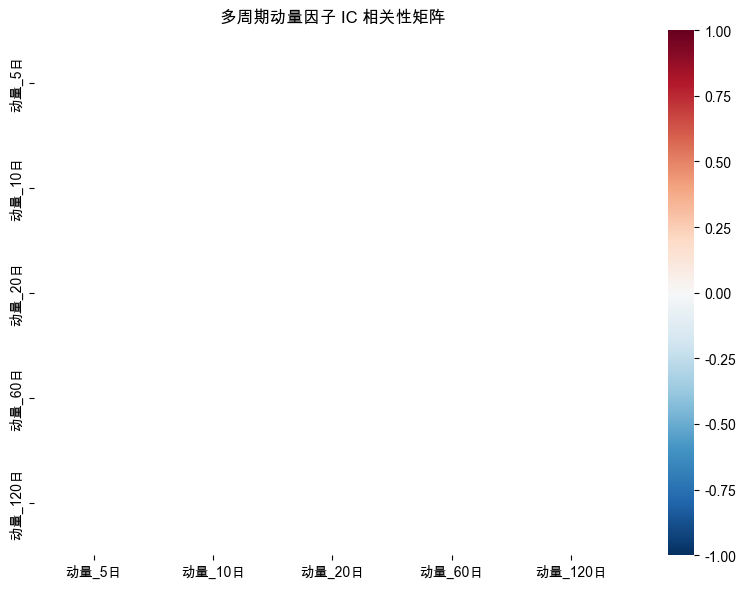


IC 相关性矩阵：
         动量_5日  动量_10日  动量_20日  动量_60日  动量_120日
动量_5日      NaN     NaN     NaN     NaN      NaN
动量_10日     NaN     NaN     NaN     NaN      NaN
动量_20日     NaN     NaN     NaN     NaN      NaN
动量_60日     NaN     NaN     NaN     NaN      NaN
动量_120日    NaN     NaN     NaN     NaN      NaN


In [9]:
# 多周期动量因子之间的 IC 相关性
ic_df = pd.DataFrame({f"动量_{p}日": ic_series_dict[p] for p in PERIODS}).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
corr = ic_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            vmin=-1, vmax=1)
ax.set_title("多周期动量因子 IC 相关性矩阵")
plt.tight_layout()
plt.show()

print("\nIC 相关性矩阵：")
print(corr.to_string())

【等权合成动量】IC 统计摘要
  IC 均值    : nan
  IC 标准差  : nan
  ICIR       : nan
  IC>0 占比  : nan%
  t 统计量   : nan  (|t|>2 视为显著)



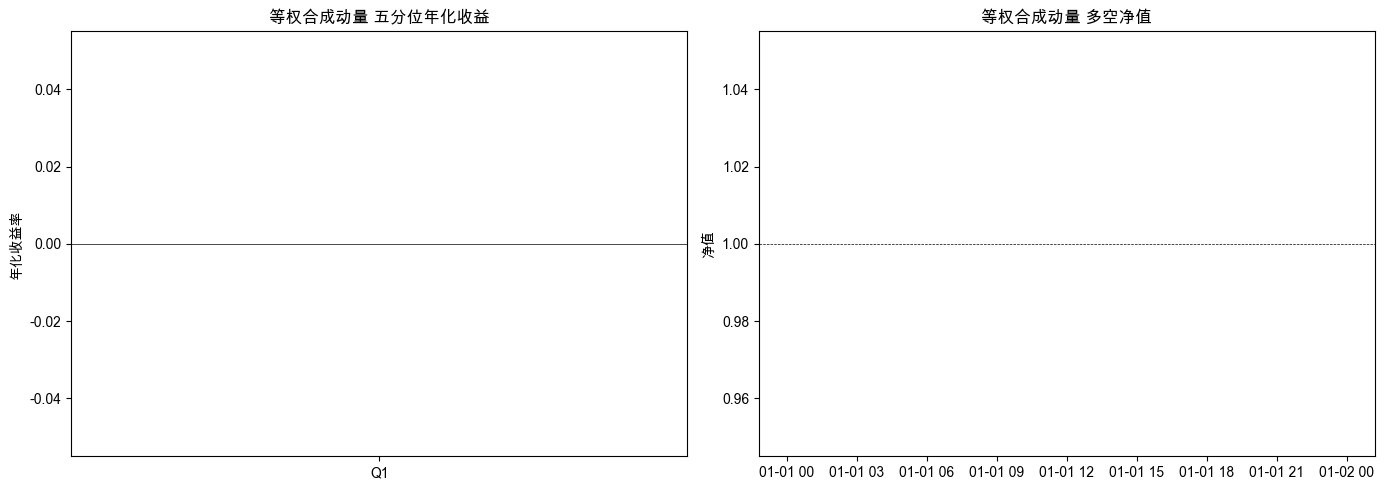

In [10]:
# 等权合成动量因子
composite = equal_weight_composite(momentum_factors)

# 合成因子 IC 分析
ic_composite = compute_ic_series(composite, fwd_ret, method="spearman")
composite_summary = ic_summary(ic_composite, name="等权合成动量")

# 合成因子分层回测
group_ret_comp, ls_ret_comp = quintile_backtest(composite, fwd_ret, n_groups=5, long_short="Qn_minus_Q1")

# 合成因子净值曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：分层收益
avg_ret = group_ret_comp.mean() * 252
colors = ["#d73027" if v < 0 else "#4575b4" for v in avg_ret.values]
axes[0].bar(avg_ret.index, avg_ret.values, color=colors, alpha=0.8)
axes[0].set_title("等权合成动量 五分位年化收益")
axes[0].set_ylabel("年化收益率")
axes[0].axhline(0, color="black", linewidth=0.5)

# 右：多空净值
cum_ret = (1 + ls_ret_comp.dropna()).cumprod()
axes[1].plot(cum_ret.index, cum_ret.values, color="steelblue", linewidth=1.5)
axes[1].set_title("等权合成动量 多空净值")
axes[1].set_ylabel("净值")
axes[1].axhline(1, color="black", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

## 6. 结论

### A 股动量 vs 反转

根据以上分析，总结 A 股市场的动量/反转效应特征。

In [11]:
# 汇总所有因子的关键指标
print("=" * 70)
print("  动量因子研究结论汇总")
print("=" * 70)
print()

# 判断动量还是反转
for p in PERIODS:
    s = ic_summaries[p]
    direction = "动量" if s["IC_mean"] > 0 else "反转"
    sig = "显著" if abs(s["t_stat"]) > 2 else "不显著"
    print(f"  {p:>3d}日: IC={s['IC_mean']:+.4f}, ICIR={s['ICIR']:+.4f}, t={s['t_stat']:+.4f} → {direction}效应（{sig}）")

print()
print(f"  等权合成: IC={composite_summary['IC_mean']:+.4f}, ICIR={composite_summary['ICIR']:+.4f}")
print()
print("=" * 70)
print()
print("分析要点：")
print("  1. A股短期（5-20日）通常表现为反转效应（IC<0），长期（60-120日）可能有弱动量")
print("  2. 反转效应与极坐标价量因子的反转逻辑一致，两者可能高度相关")
print("  3. 如果动量和极坐标因子高度相关，组合价值有限")
print("  4. 如果低相关，可以考虑将两者组合以获取更稳健的 alpha")

  动量因子研究结论汇总

    5日: IC=+nan, ICIR=+nan, t=+nan → 反转效应（不显著）
   10日: IC=+nan, ICIR=+nan, t=+nan → 反转效应（不显著）
   20日: IC=+nan, ICIR=+nan, t=+nan → 反转效应（不显著）
   60日: IC=+nan, ICIR=+nan, t=+nan → 反转效应（不显著）
  120日: IC=+nan, ICIR=+nan, t=+nan → 反转效应（不显著）

  等权合成: IC=+nan, ICIR=+nan


分析要点：
  1. A股短期（5-20日）通常表现为反转效应（IC<0），长期（60-120日）可能有弱动量
  2. 反转效应与极坐标价量因子的反转逻辑一致，两者可能高度相关
  3. 如果动量和极坐标因子高度相关，组合价值有限
  4. 如果低相关，可以考虑将两者组合以获取更稳健的 alpha
